<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


---

**Resolución**

Como corpus uso el mismo del Desafío 2, las letras de Las Pastillas del Abuelo que bajé de letras.com con el script `scrap_letras.py`. Son 141 canciones con un verso por línea en `dataset/pastillas_del_abuelo.txt` y la cantidad de versos de cada una en `dataset/canciones.csv`.

Entreno tres redes many to many, una SimpleRNN, una LSTM y una GRU, y las comparo por perplejidad en validación. Después genero letras con greedy, beam search determinista y beam search estocástico con distintas temperaturas.

Para entrenar en la GPU del M1 Pro uso keras 3 con el backend de torch, que detecta MPS solo. TensorFlow en este entorno no ve la GPU.

In [2]:
import os

os.environ["KERAS_BACKEND"] = "torch"  # env var antes de importar keras

In [3]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras
from keras import layers
from sklearn.model_selection import train_test_split

In [4]:
keras.utils.set_random_seed(42)

print(f"Backend: {keras.backend.backend()}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"Device: {keras.ops.zeros(1).device}")

Backend: torch
MPS disponible: True
Device: mps:0


#### Carga del corpus

El txt tiene los versos en el mismo orden que el csv, así que con los conteos reconstruyo cada canción. Paso todo a minúsculas de entrada, ya que a nivel caracter "l" y "L" son dos tokens distintos. Las mayúsculas aparecen más que todo al principio de cada verso, por lo que sacarlas y simplificar lo que tiene que aprender el modelo vale la pena. Sin ellas el vocabulario baja de 90 a 62 caracteres.

In [ ]:
versos = Path("dataset/pastillas_del_abuelo.txt").read_text(encoding="utf-8").lower().splitlines()
canciones = pd.read_csv("dataset/canciones.csv")

# reconstruyo cada cancion como lista de versos con los conteos del csv
letras, i = [], 0
for n in canciones["versos"]:
    letras.append(versos[i:i + n])
    i += n

print(f"Cantidad de canciones: {len(letras)}")
print(f"Cantidad de versos: {len(versos)}")
print(f"Cantidad de caracteres: {sum(len(v) + 1 for v in versos)}")
print(f"\n{'\n'.join(letras[1][:6])}")

Cantidad de canciones: 141
Cantidad de versos: 5147
Cantidad de caracteres: 158700

ya no me encuentro preguntando sobre amor
por fin, no hay nada que pretenda no saber
entiendo que no hay relación
entre amar y envejecer
ya no me encuentro preguntando cómo dar
por fin, comparto por el miedo de perder


### Tokenización por caracteres

El vocabulario es el conjunto de caracteres del corpus, ordenado para que el mapeo sea siempre el mismo entre corridas (cuando lo ordenamos pasa a ser una lista). 

Los índices arrancan en 1 y dejo el 0 reservado para padding. 

In [11]:
vocab = sorted(set("\n".join(versos)))  # https://stackoverflow.com/a/17458090/8902782
char2idx = {c: i for i, c in enumerate(vocab, start=1)}  # 0 reservado para padding
idx2char = {i: c for c, i in char2idx.items()}

VOCAB_SIZE = len(vocab)
NUM_TOKENS = VOCAB_SIZE + 1

print(f"Tamaño del vocabulario: {VOCAB_SIZE}")
print(f"Tokens + padding: {NUM_TOKENS}")
"".join(vocab)

Tamaño del vocabulario: 62
Tokens + padding: 63


'\n !"%\'(),-.0123456789:?[]abcdefghijklmnopqrstuvwxyz¡«»¿áéíñóúü'

### Tamaño del contexto

Veamos cuántos caracteres tiene un verso para elegir nuestra ventana de contexto.

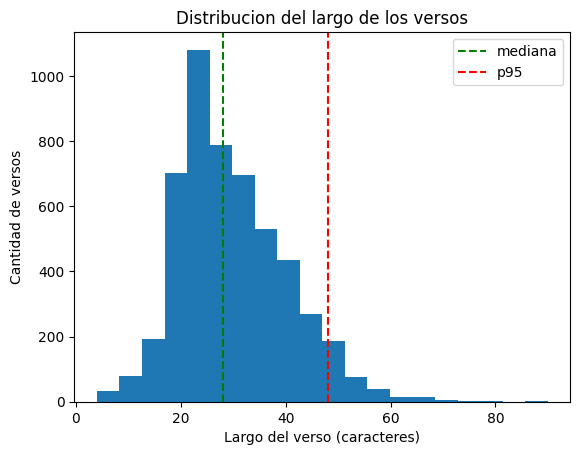

count    5147.0
mean       29.8
std        10.3
min         4.0
25%        23.0
50%        28.0
75%        37.0
90%        44.0
95%        48.0
max        90.0
dtype: float64

In [13]:
largos = [len(v) for v in versos]

plt.hist(largos, bins=20)
plt.axvline(np.median(largos), color="green", linestyle="--", label="mediana")
plt.axvline(np.percentile(largos, 95), color="red", linestyle="--", label="p95")
plt.xlabel("Largo del verso (caracteres)")
plt.ylabel("Cantidad de versos")
plt.title("Distribucion del largo de los versos")
plt.legend()
plt.show()

pd.Series(largos).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(1)

In [16]:
# el contexto tiene que cubrir al menos 2 versos completos al p95 (+1 por el salto de linea)
p95 = np.percentile(largos, 95)
MAX_CONTEXT_SIZE = 100

print(f"2 versos al p95: {2 * (p95 + 1):.0f} caracteres")
print(f"Mediana de versos por contexto: {MAX_CONTEXT_SIZE / (np.median(largos) + 1):.1f}")
print(f"Contexto final a usar: {MAX_CONTEXT_SIZE} caracteres")

2 versos al p95: 98 caracteres
Mediana de versos por contexto: 3.4
Contexto final a usar: 100 caracteres


La distribución tiene la mayoría de los versos entre veinte y cuarenta caracteres y una cola larga a la derecha. Si tomara el percentil 95 de un verso como contexto, el modelo vería como mucho un verso a la vez y nunca el anterior completo. Para una letra eso me parece poco, porque la rima se arma entre versos consecutivos. Por eso el criterio que uso es que la ventana cubra al menos dos versos completos al percentil 95, contando el salto de línea de cada uno, y redondeo a 100 caracteres. Con la mediana vemos que en general entran más de tres versos en la ventana.

### Split de train y validación

Separo por canciones, para evitar cortar versos, 80/20 aleatorio con semilla fija.

In [17]:
textos = ["\n".join(letra) for letra in letras]
textos_train, textos_val = train_test_split(textos, test_size=0.2, random_state=42)

print(f"Canciones train: {len(textos_train)} | val: {len(textos_val)}")
print(f"Caracteres train: {sum(map(len, textos_train))} | val: {sum(map(len, textos_val))}")

Canciones train: 112 | val: 29
Caracteres train: 125251 | val: 33308


### Estructura del dataset

El modelo es many to many. Cada ventana de entrada tiene 100 caracteres y el target es la misma ventana corrida un caracter a la derecha, así que en cada paso de tiempo la red predice el caracter siguiente. 

Las ventanas de train las armo con un stride de 10 caracteres, pues con 1 como estaba el ejemplo el entrenamiento tardaba muchísimo tiempo por época. 

Para validación uso ventanas sin solapamiento, así cada caracter de validación se evalúa una sola vez.

In [18]:
STRIDE = 10  # con stride 1 el entrenamiento tarda mucho tiempo
STRIDE_VAL = MAX_CONTEXT_SIZE  # sin solapamiento


def armar_ventanas(textos, stride):
    """Ventanas x de MAX_CONTEXT_SIZE caracteres y su y corrido en 1, dentro de cada cancion."""
    x, y = [], []
    for texto in textos:
        ids = [char2idx[c] for c in texto]
        for i in range(0, len(ids) - MAX_CONTEXT_SIZE, stride):
            x.append(ids[i:i + MAX_CONTEXT_SIZE])
            y.append(ids[i + 1:i + MAX_CONTEXT_SIZE + 1])
    return np.array(x, dtype="int32"), np.array(y, dtype="int32")

In [19]:
X_train, y_train = armar_ventanas(textos_train, STRIDE)
X_val, y_val = armar_ventanas(textos_val, STRIDE_VAL)

# chequeo: y es x corrido en 1
assert (X_train[0, 1:] == y_train[0, :-1]).all()

In [28]:
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val: {X_val.shape} | y_val: {y_val.shape}")

X_train: (11452, 100) | y_train: (11452, 100)
X_val: (320, 100) | y_val: (320, 100)


In [27]:
print("".join(idx2char[i] for i in X_train[0]))

crees saber que está a tu alcance
y no lo está
se muestra infiel
espera su oportunidad
si pinta bien


### Definición de los modelos

Las tres redes comparten la misma estructura y solo cambia la capa recurrente:
* Entrada: son los índices de los caracteres y la primera capa los pasa a one-hot con CategoryEncoding. 
* Capa recurrente: usa return_sequences para que devuelva la salida de cada paso de tiempo.
* Salida: Dense con softmax y TimeDistributed, que aplica la misma Dense en cada paso y predice el caracter siguiente en cada posición.
* Loss: sparse categorical crossentropy, que toma los índices del target sin necesidad de pasarlos a one-hot. 
* Optimizador: rmsprop como sugiere la cátedra.
* Perplejidad: la calculo como la exponencial de la loss de validación.

In [29]:
UNIDADES = 256
EPOCAS = 100
PACIENCIA = 5
BATCH_SIZE = 256


def armar_modelo(capa_recurrente):
    """One-hot, capa recurrente many to many y softmax por paso de tiempo."""
    modelo = keras.Sequential([
        keras.Input(shape=(None,)),
        layers.CategoryEncoding(num_tokens=NUM_TOKENS, output_mode="one_hot"),
        capa_recurrente(UNIDADES, return_sequences=True),
        layers.TimeDistributed(layers.Dense(NUM_TOKENS, activation="softmax")),
    ])
    modelo.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")
    return modelo

In [30]:
class Perplejidad(keras.callbacks.Callback):
    """Agrega val_ppl = exp(val_loss) a los logs de cada epoca."""

    def on_epoch_end(self, epoch, logs=None):
        logs["val_ppl"] = float(np.exp(logs["val_loss"]))
        print(f" - val_ppl: {logs['val_ppl']:.2f}")


def entrenar(nombre, modelo):
    """Entrena con early stopping y guarda el mejor modelo segun la perplejidad de validacion."""
    callbacks = [
        Perplejidad(),  # va primero para que los siguientes ya vean val_ppl
        keras.callbacks.ModelCheckpoint(f"modelo_{nombre}.keras", monitor="val_ppl", mode="min", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_ppl", mode="min", patience=PACIENCIA, restore_best_weights=True),
    ]
    inicio = time.time()
    historia = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCAS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )
    duracion = time.time() - inicio
    print(f"Tiempo: {duracion / 60:.1f} min")
    print(f"Mejor perplejidad: {min(historia.history['val_ppl']):.2f}")
    return historia.history, duracion

In [33]:
historias, tiempos = {}, {}

#### SimpleRNN

Es la más simple, pero como el gradiente pasa por la misma matriz en cada paso tiende a desvanecerse con contextos largos.

In [32]:
simple_rnn = armar_modelo(layers.SimpleRNN)
simple_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ category_encoding_1             │ (None, None, 63)       │             0 │
│ (CategoryEncoding)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 256)      │        81,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, None, 63)       │        16,191 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,111 (383.25 KB)

 Trainable params: 98,111 (383.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historias["SimpleRNN"], tiempos["SimpleRNN"] = entrenar("SimpleRNN", simple_rnn)

Epoch 1/100


 - val_ppl: 16.57
45/45 - 11s - 236ms/step - loss: 3.0338 - val_loss: 2.8079 - val_ppl: 16.5745


Epoch 2/100


 - val_ppl: 12.84
45/45 - 10s - 223ms/step - loss: 2.6574 - val_loss: 2.5529 - val_ppl: 12.8448


Epoch 3/100


...

Epoch 20/100


 - val_ppl: 8.32
45/45 - 9s - 208ms/step - loss: 1.7908 - val_loss: 2.1192 - val_ppl: 8.3241


Epoch 21/100


 - val_ppl: 8.37
45/45 - 9s - 211ms/step - loss: 1.7713 - val_loss: 2.1241 - val_ppl: 8.3651


Tiempo: 3.4 min
Mejor perplejidad: 8.30


#### LSTM

Agrega una memoria de largo plazo separada del estado oculto y tres compuertas que regulan cuánto de la entrada se guarda, cuánto de la memoria anterior se olvida y cuánto de la memoria pasa a la salida. Esa memoria deja propagar el gradiente a mayor profundidad temporal, que es justo lo que le falta a la SimpleRNN. Tiene cuatro veces más parámetros por unidad.

In [ ]:
lstm = armar_modelo(layers.LSTM)
lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ category_encoding_2             │ (None, None, 63)       │             0 │
│ (CategoryEncoding)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 256)      │       327,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 63)       │        16,191 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,871 (1.31 MB)

 Trainable params: 343,871 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historias["LSTM"], tiempos["LSTM"] = entrenar("LSTM", lstm)

Epoch 1/100


 - val_ppl: 19.95
45/45 - 13s - 291ms/step - loss: 3.1305 - val_loss: 2.9932 - val_ppl: 19.9492


Epoch 2/100


 - val_ppl: 18.85
45/45 - 13s - 281ms/step - loss: 2.9516 - val_loss: 2.9365 - val_ppl: 18.8502


Epoch 3/100


...

Epoch 99/100


 - val_ppl: 6.33
45/45 - 12s - 278ms/step - loss: 1.6783 - val_loss: 1.8454 - val_ppl: 6.3306


Epoch 100/100


 - val_ppl: 6.26
45/45 - 12s - 277ms/step - loss: 1.6747 - val_loss: 1.8335 - val_ppl: 6.2557


Tiempo: 20.9 min
Mejor perplejidad: 6.26


#### GRU

Es una simplificación de la LSTM. No tiene una memoria separada del estado oculto y usa dos compuertas en lugar de tres, una de reset y una de update. Tiene tres veces los parámetros de la SimpleRNN por unidad, así que queda entre las otras dos en costo.

In [35]:
gru = armar_modelo(layers.GRU)
gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ category_encoding_3             │ (None, None, 63)       │             0 │
│ (CategoryEncoding)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       246,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 63)       │        16,191 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,719 (1.00 MB)

 Trainable params: 262,719 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historias["GRU"], tiempos["GRU"] = entrenar("GRU", gru)

Epoch 1/100


 - val_ppl: 18.62
45/45 - 13s - 289ms/step - loss: 3.1591 - val_loss: 2.9243 - val_ppl: 18.6213


Epoch 2/100


 - val_ppl: 14.66
45/45 - 13s - 289ms/step - loss: 2.8024 - val_loss: 2.6852 - val_ppl: 14.6617


Epoch 3/100


...

Epoch 49/100


 - val_ppl: 6.10
45/45 - 13s - 284ms/step - loss: 1.4436 - val_loss: 1.8075 - val_ppl: 6.0953


Epoch 50/100


 - val_ppl: 6.11
45/45 - 13s - 284ms/step - loss: 1.4258 - val_loss: 1.8094 - val_ppl: 6.1065


Tiempo: 10.7 min
Mejor perplejidad: 6.07


### Comparación de las tres redes

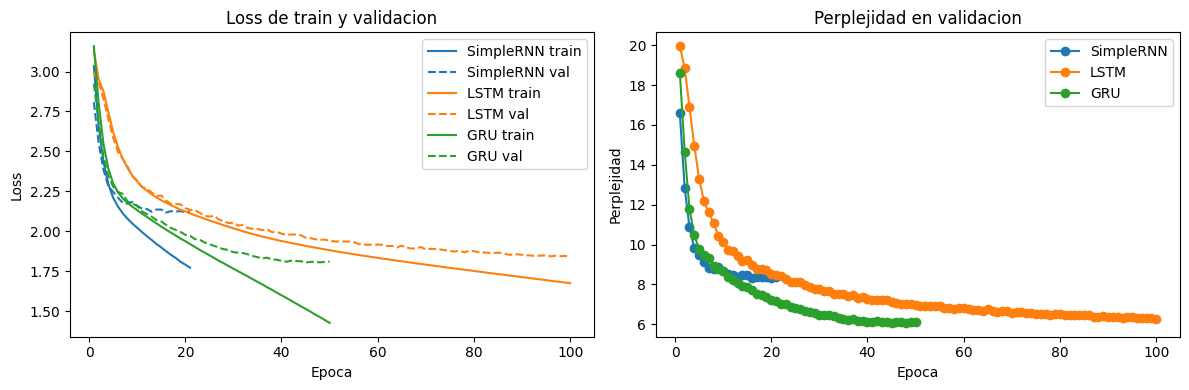

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for nombre, historia in historias.items():
    epocas = range(1, len(historia["loss"]) + 1)
    linea, = ax1.plot(epocas, historia["loss"], label=f"{nombre} train")
    ax1.plot(epocas, historia["val_loss"], linestyle="--", color=linea.get_color(), label=f"{nombre} val")
    ax2.plot(epocas, historia["val_ppl"], marker="o", label=nombre)
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Loss")
ax1.set_title("Loss de train y validacion")
ax1.legend()
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Perplejidad")
ax2.set_title("Perplejidad en validacion")
ax2.legend()
plt.tight_layout()
plt.show()

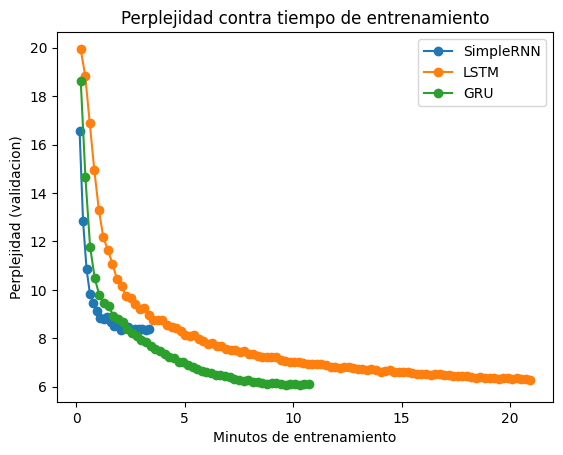

In [17]:
# perplejidad contra tiempo acumulado de entrenamiento, para ver cual llega mas rapido
for nombre, historia in historias.items():
    n = len(historia["val_ppl"])
    minutos = np.arange(1, n + 1) * tiempos[nombre] / n / 60
    plt.plot(minutos, historia["val_ppl"], marker="o", label=nombre)
plt.xlabel("Minutos de entrenamiento")
plt.ylabel("Perplejidad (validacion)")
plt.title("Perplejidad contra tiempo de entrenamiento")
plt.legend()
plt.show()

In [18]:
resumen = pd.DataFrame({
    nombre: {
        "mejor_ppl": min(historia["val_ppl"]),
        "mejor_epoca": int(np.argmin(historia["val_ppl"])) + 1,
        "epocas": len(historia["val_ppl"]),
        "minutos": tiempos[nombre] / 60,
    }
    for nombre, historia in historias.items()
}).T
resumen.round(2)

,mejor_ppl,mejor_epoca,epocas,minutos
SimpleRNN,8.30,16.0,21.0,3.37
LSTM,6.26,100.0,100.0,20.94
GRU,6.07,45.0,50.0,10.73


Observaciones:
* La GRU y la LSTM quedan muy cerca entre sí y por debajo de la SimpleRNN, que es la que peor perplejidad alcanza. 
* La SimpleRNN corta rápido por early stopping porque no mejora la métrica, algo que va en línea con el problema del desvanecimiento del gradiente en ventanas largas. 
* La GRU es la que mejor perplejidad logra, con la mitad de las épocas que la LSTM. 
* La LSTM llega al máximo de épocas con la perplejidad todavía bajando de a poco, así que con más tiempo de entrenamiento probablemente empate a la GRU. Por época es la más lenta de las tres y en la curva de perplejidad contra tiempo se ve que la GRU alcanza un mejor valor antes.

### Generación de secuencias

Cargo los mejores pesos de cada red desde los archivos que guardó el checkpoint y armo tres estrategias de generación:

* Greedy toma en cada paso el caracter más probable. 

* Beam search determinista mantiene en cada paso los k caminos con mayor log-probabilidad acumulada.

* Beam search estocástico hace lo mismo pero con un muestreo aleatorio y agregando la temperatura.

Los caracteres que no están en el vocabulario se descartan con un aviso.

In [36]:
modelos = {nombre: keras.models.load_model(f"modelo_{nombre}.keras") for nombre in ("SimpleRNN", "LSTM", "GRU")}
list(modelos)

['SimpleRNN', 'LSTM', 'GRU']

In [37]:
from scipy.special import softmax


def encode(texto):
    """Texto a indices, descarta caracteres fuera del vocabulario y avisa."""
    texto = texto.lower()
    fuera = sorted({c for c in texto if c not in char2idx})
    if fuera:
        print(f"Aviso, caracteres fuera del vocabulario descartados: {fuera}")
    tokens = [char2idx[c] for c in texto if c in char2idx]
    if not tokens:
        raise ValueError(f"el seed {texto!r} no tiene caracteres del vocabulario")
    return tokens


def decode(tokens):
    """Indices a texto, ignora el padding."""
    return "".join(idx2char[t] for t in tokens if t != 0)


def log_probs_siguiente(modelo, secuencias):
    """Log-probs del proximo caracter para un batch de secuencias del mismo largo, un solo predict."""
    x = np.array([s[-MAX_CONTEXT_SIZE:] for s in secuencias])  # sin padding, todos los caminos miden lo mismo
    probs = modelo.predict_on_batch(x)[:, -1, :].astype("float64")
    log_p = np.log(probs + 1e-10)
    log_p[:, 0] = -np.inf  # nunca generar padding
    return log_p

##### Greedy

In [38]:
def greedy(modelo, seed, n_chars=200):
    """Genera n_chars eligiendo siempre el caracter mas probable."""
    tokens, log_p_total = encode(seed), 0.0
    for _ in range(n_chars):
        log_p = log_probs_siguiente(modelo, [tokens])[0]
        siguiente = int(np.argmax(log_p))
        tokens.append(siguiente)
        log_p_total += log_p[siguiente]
    return decode(tokens), log_p_total

##### Beam search determinista y estocástico

In [39]:
def beam_search(modelo, seed, n_chars=200, num_beams=5, modo="det", temp=1.0):
    """Beam search det o sto, devuelve [(texto, log_p)] de mejor a peor."""
    if modo not in ("det", "sto"):
        raise ValueError(f"modo invalido {modo!r}, usar 'det' o 'sto'")
    beams, log_p_beams = [encode(seed)], np.zeros(1)  # un solo camino al inicio
    for _ in range(n_chars):
        log_p = log_probs_siguiente(modelo, beams)  # (n_beams, NUM_TOKENS)
        vocab = log_p.shape[1]
        candidatos = (log_p_beams[:, None] + log_p).ravel()  # log-prob acumulada real
        if modo == "det":
            elegidos = np.argsort(candidatos)[::-1][:num_beams]
        else:
            # la temperatura solo afecta la distribucion del paso actual
            pesos = softmax((log_p_beams[:, None] + log_p / temp).ravel())
            elegidos = np.random.choice(len(pesos), size=num_beams, replace=False, p=pesos)
        beams = [beams[i // vocab] + [int(i % vocab)] for i in elegidos]
        log_p_beams = candidatos[elegidos]
    orden = np.argsort(log_p_beams)[::-1]
    return [(decode(beams[i]), float(log_p_beams[i])) for i in orden]

##### Test caracter fuera del vocabulario

In [ ]:
# chequeo con un seed que tiene un caracter fuera del vocabulario
np.random.seed(42)
salida = beam_search(modelos["LSTM"], "hola ☺ ", n_chars=20, num_beams=4, modo="sto", temp=1.5)
textos_beam = [t for t, _ in salida]
log_ps = [lp for _, lp in salida]
assert len(set(textos_beam)) == 4, "caminos repetidos"
assert log_ps == sorted(log_ps, reverse=True), "caminos no ordenados"
assert all(t.startswith("hola  ") for t in textos_beam), "falta el seed"
assert all(len(t) == len("hola  ") + 20 for t in textos_beam)
for texto, lp in salida:
    print(f"{lp:8.2f} | {texto!r}")

Aviso, caracteres fuera del vocabulario descartados: ['☺']
  -26.72 | 'hola  la dibe entra amor\ny'
  -26.92 | 'hola  la dibe entra amor\nd'
  -27.34 | 'hola  la dibe entra amor\nq'
  -27.96 | 'hola  la dibe entra amor\ns'


#### Generación con las tres redes

Uso tres seeds cortos en minúscula con el tono de las letras de la banda. Uno termina en salto de línea para ver si el modelo arranca un verso nuevo. Genero 200 caracteres con 5 caminos y pruebo tres temperaturas. Antes de cada corrida estocástica fijo la semilla, así cada resultado se puede reproducir por separado.

Muestro la log-probabilidad acumulada y la perplejidad del modelo sobre su propio texto generado, que es útil para ver el efecto de la temperatura.

In [41]:
seeds = ["esta noche ", "en el barrio\n", "no me digas que "]
N_CHARS = 200
NUM_BEAMS = 5
TEMPS = [0.5, 1.0, 1.5]
SEMILLA = 42


def fila(seed, nombre, estrategia, texto, log_p):
    """Arma una fila de resultados con la perplejidad propia."""
    return {
        "seed": seed, 
        "modelo": nombre,
        "estrategia": estrategia, 
        "log_p": log_p,
        "ppl_propia": np.exp(-log_p / N_CHARS), 
        "texto": texto
    }


resultados = []
for seed in seeds:
    for nombre, modelo in modelos.items():
        texto, log_p = greedy(modelo, seed, N_CHARS)
        resultados.append(fila(seed, nombre, "greedy", texto, log_p))
        texto, log_p = beam_search(modelo, seed, N_CHARS, NUM_BEAMS, "det")[0]
        resultados.append(fila(seed, nombre, "beam det", texto, log_p))
        for t in TEMPS:
            np.random.seed(SEMILLA)
            texto, log_p = beam_search(modelo, seed, N_CHARS, NUM_BEAMS, "sto", t)[0]
            resultados.append(fila(seed, nombre, f"beam sto T={t}", texto, log_p))

df_gen = pd.DataFrame(resultados)
df_gen.shape

(45, 6)

In [42]:
# para cada seed y estrategia, los textos de las 3 redes uno debajo del otro
for (seed, estrategia), grupo in df_gen.groupby(["seed", "estrategia"], sort=False):
    print(f"{'=' * 80}\nseed: {seed!r} | {estrategia}")
    for f in grupo.itertuples():
        print(f"--- {f.modelo} (log_p={f.log_p:.1f}, ppl={f.ppl_propia:.2f})\n{f.texto}\n")

seed: 'esta noche ' | greedy
--- SimpleRNN (log_p=-227.0, ppl=3.11)
esta noche la vidar
por el ciendo an mero
y conter en miso
y so prende de la gunar
se presento se miende ta pero de para de vidar en la ciento
y con teno cuento me tuda e poros
la más que ta mendo al pora de por

--- LSTM (log_p=-207.1, ppl=2.82)
esta noche la cara
con esta ser la cariciando el mirar
pero esta ser la para de la cara
con esta cara de la cara de la cara
con esta cara de la cara de la cara
con esta cara de la cara de la cara
con esta cara d

--- GRU (log_p=-194.4, ppl=2.64)
esta noche esta a esta terrando en el carizo
y ahí es mi amor no se sue tengo mis pero ya no es el carizo
y ahí es mi amor no se sue tengo mis pero ya no es el carizo
y ahí es mi amor no se sue tengo mis pero ya

seed: 'esta noche ' | beam det
--- SimpleRNN (log_p=-188.6, ppl=2.57)
esta noche con es me hay que pero tengo que estrestros de lastar
porque hoy que pero pera do que el ciendo en cuendo en lo que estás que tengo que hay que e

In [43]:
# perplejidad del modelo sobre su propio texto generado, menor es mas confiado
df_gen.pivot_table(index=["seed", "estrategia"], columns="modelo", values="ppl_propia", sort=False).round(2)

modelo                           SimpleRNN  LSTM   GRU
seed             estrategia                           
esta noche       greedy               3.11  2.82  2.64
                 beam det             2.57  2.08  2.04
                 beam sto T=0.5       2.92  2.40  2.34
                 beam sto T=1.0       3.58  2.85  2.73
                 beam sto T=1.5       4.72  3.28  2.99
en el barrio\n   greedy               3.21  2.73  2.53
                 beam det             2.58  2.08  2.01
                 beam sto T=0.5       2.77  2.39  2.09
                 beam sto T=1.0       3.48  2.91  2.59
                 beam sto T=1.5       4.24  3.25  2.85
no me digas que  greedy               3.14  2.73  2.55
                 beam det             2.57  2.05  2.01
                 beam sto T=0.5       2.94  2.53  2.11
                 beam sto T=1.0       3.74  2.98  2.43
                 beam sto T=1.5       4.50  3.17  3.36

Es interesante notar cómo con greedy y beam search determinista en LSTM y GRU se obtiene una baja perplejidad, pero los textos son loops de lo mismo, como por ejemplo:

```python
seed: 'no me digas que ' | greedy
--- SimpleRNN (log_p=-228.7, ppl=3.14)
no me digas que te mina
y te que la labar
que de sibar es la arte
y sun ten lo que me conte lo vera des
para las el conder el mero
y an porque se para nos en entresta de entor
al meso ta más
pero de vida de presida d

--- LSTM (log_p=-201.0, ppl=2.73)
no me digas que el contro
y la permitado en la carazón
de esta cara de la cara de la cara
con esta cara de la cara de la cara
con esta cara de la cara de la cara
con esta cara de la cara de la cara
con esta cara de l

--- GRU (log_p=-186.9, ppl=2.55)
no me digas que se se vien a contrar
en la cuenta de esta la vida y la consumiento
si me ver que está en el carizo
y ahí es mi amor no se sue tengo mis pero ya no es el carizo
y ahí es mi amor no se sue tengo mis per

seed: 'no me digas que ' | beam det
--- SimpleRNN (log_p=-188.5, ppl=2.57)
no me digas que estados
y los que estás destados
que entestrabla que estenta
y contendo de piendo
y los que hay me dejos que estesta biendos
que entra que el ciendo en corozón
porque hay que el ciento que estás que t

--- LSTM (log_p=-143.5, ppl=2.05)
no me digas que el corazón
siempre el amor de lo que el corazón
siempre el amor de lo que el corazón
siempre el amor de lo que el corazón
siempre el amor de lo que el corazón
siempre el amor de lo que el corazón
que 

--- GRU (log_p=-139.3, ppl=2.01)
no me digas que no tengo un sueño
que el tiempo en el tiempo en el tiempo
en la conciencia más
que el tiempo en el tiempo en el tiempo
en la conciencia más
que el tiempo en el tiempo en el tiempo
en la conciencia el 
```

Esto pasa porque siempre se elige el caracter con la probabilidad más alta y es determinista, entonces si después de "con esta cara de la cara de la cara" lo más probable es "con" el modelo vuelve a predecir exactamente lo mismo y entra en un bucle infinito. Con la SimpleRNN eso no pasa porque tiene la perplejidad más alta, sus probabilidades están más repartidas y su memoria es más corta, entonces cualquier variación en los últimos caracteres le cambia la elección del próximo caracter.

Beam search estocástico parece escribir mejor. Con respecto a la temperatura, cuando es baja el modelo repite más. Al aumentarla la perplejidad sube y el modelo parece escribir más palabras sin sentido, debido a que puede elegir más caracteres de los que no está tan seguro:

```python
seed: 'en el barrio\n' | beam sto T=0.5
--- GRU (log_p=-147.5, ppl=2.09)
en el barrio
del que estás corazón
siempre esta la vida y tengo una por que para el tiempo
siempre esta la historia
pero no, no, no, no sé que esperando en el tiempo
siempre esta la inciente
siempre un amigo en el

seed: 'en el barrio\n' | beam sto T=1.0
--- GRU (log_p=-190.3, ppl=2.59)
en el barrio
que se confendiendo una vez mi amor
no habrá que se va a para el combler
es que la respueste y contras en el bien
quiero ser tu contestados
noches que hay que estás como la rezandar
un solo es que el 

seed: 'en el barrio\n' | beam sto T=1.5
--- GRU (log_p=-209.8, ppl=2.85)
en el barrio
que el arte en esta escupar
las ojas que dejustinedos
que atros en llamanto con los del sonor
siempre está la vida más
y este la ver qué es solo habero
siempre esta la inciente de amor
ya no es el ham
```

Por último me llama mucho la atención cómo una red súper simple con un corpus chico puede tener noción de versos, entender cuándo tiene que poner un salto de línea y cómo puede generar palabras que tienen sentido, conectando caracter a caracter. Si bien las frases de la canción no son como para sacar el próximo hit, el resultado de los modelos, por ser muy chicos, creo que es bueno.

### Interfaz interactiva

Los tres modelos quedaron guardados en archivos `.keras` y se pueden cargar en cualquier momento sin reentrenar. Con gradio armo una interfaz para elegir el modelo, el seed, la estrategia y sus parámetros y ver el texto generado.

In [45]:
import gradio as gr


def generar(nombre, seed, estrategia, temp, n_chars, num_beams):
    """Genera texto con el modelo y la estrategia elegidos en la interfaz."""
    modelo = modelos[nombre]
    if estrategia == "greedy":
        texto, log_p = greedy(modelo, seed, int(n_chars))
    else:
        modo = "det" if estrategia == "beam determinista" else "sto"
        texto, log_p = beam_search(modelo, seed, int(n_chars), int(num_beams), modo, temp)[0]
    return texto, round(log_p, 2)


iface = gr.Interface(
    fn=generar,
    inputs=[
        gr.Dropdown(list(modelos), value="LSTM", label="Modelo"),
        gr.Textbox(value="esta noche ", label="Seed"),
        gr.Radio(["greedy", "beam determinista", "beam estocastico"], value="beam estocastico", label="Estrategia"),
        gr.Slider(0.2, 2.0, value=1.0, step=0.1, label="Temperatura (solo estocastico)"),
        gr.Slider(20, 400, value=200, step=10, label="Caracteres a generar"),
        gr.Slider(1, 10, value=5, step=1, label="Caminos del beam search"),
    ],
    outputs=[gr.Textbox(label="Texto generado", lines=8), gr.Number(label="Log-prob acumulada")],
)
iface.launch(prevent_thread_lock=True)  # no bloquea la ejecucion del notebook

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio/flagged/dataset1.csv


### Conclusiones

De las tres redes me quedo con la GRU. Es la que mejor perplejidad logra, entrena en la mitad del tiempo que la LSTM y sus letras son las que mejor se leen. La LSTM queda muy cerca y con más épocas seguramente la empata. La SimpleRNN aprende la forma de los versos y las palabras cortas, pero queda arriba en perplejidad frente a las otras con memoria de largo plazo.

De las estrategias, greedy y beam determinista dan las secuencias más probables pero terminan en bucles, así que la probabilidad alta no alcanza para generar un buen texto. El beam estocástico con temperatura 1 es el que mejor balancea frases legibles con variedad entre versos. Con temperatura baja vuelve a repetir y con temperatura alta inventa demasiadas palabras.

Como trabajo futuro probaría más épocas para la LSTM, una segunda capa recurrente, un corpus más grande y un muestreo top-k o top-p como usan los LLM actuales.